# 07 · Training — the full PCA-vs-scGPT experiment matrix (512-d)

Reproducible driver for the **2 × 2 × 2 = 8-run matrix**:

- **Gene set:** `hvg5000` (top-5,000 HVG) · `all_genes` (full transcriptome)
- **Representation:** `X_pca` (**512-d**, matched to scGPT) · `X_scGPT` (512-d)
- **Task:** all-drugs (K=545) · single-task (paclitaxel, K=1)

All runs share the cell-line-grouped `split_ctrp` and a **matched trunk** (`DEFAULT_HIDDEN_DIMS = (128,64)` for both reps), so head capacity is equal and **only the input
representation differs** — a fair comparison. Single-task uses `--drugs paclitaxel` on the *same*
`split_ctrp` (not the separate `split_paclitaxel`), so its cells are apples-to-apples with the
K=545 runs. Every run calls `train_multitask.train_rep(...)` (the same function the CLI uses) and
writes a versioned `runs/<id>/` + a `runs/runs_index.csv` row.

**Per-drug-mean** predictor (predicts each drug's constant train-mean viability) is the null
model: a head only *learned* response if it beats its own drug's constant.

> **No preprocessing needed first.** Both variants already carry 512-d `X_pca`, `Y_ctrp`/`M_ctrp`
> (all 545 drugs incl. paclitaxel) and `split_ctrp` — see `05_preprocessing.ipynb`. The 512-d
> switch only required regenerating `X_pca` (done there for both variants); training reads it directly.

In [1]:
import os, sys
from pathlib import Path

NB_DIR = Path.cwd()
ROOT   = NB_DIR.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)                      # so train_rep writes runs/ at the project root

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scripts.training.train_multitask import train_rep, DEFAULT_HIDDEN_DIMS
from scripts.training.training_utils import TrainConfig
from scripts.preprocessing.layout import PipelinePaths

OUT = NB_DIR / 'outputs'
OUT.mkdir(exist_ok=True)
print('matched trunk:', DEFAULT_HIDDEN_DIMS)

matched trunk: {'X_pca': (128, 64), 'X_scGPT': (128, 64)}


In [2]:
# --- knobs -----------------------------------------------------------------
VARIANTS = ['hvg5000', 'all_genes']
REPS     = ['X_pca', 'X_scGPT']
TASKS    = {'all_drugs': None, 'single_paclitaxel': ['paclitaxel']}  # drugs arg per task
EPOCHS   = 50
SEED     = 42
# ---------------------------------------------------------------------------
config = TrainConfig(
    epochs=EPOCHS, lr=1e-3, weight_decay=1e-3, grad_clip=1.0,
    scheduler_patience=3, early_stop_patience=10, log_every=10, seed=SEED, loss='mse',
)

# Build the 8-run matrix (hvg5000 first — smaller/faster file).
MATRIX = [
    {'variant': v, 'rep': r, 'task': t, 'drugs': d}
    for v in VARIANTS for r in REPS for t, d in TASKS.items()
]
print(f'{len(MATRIX)} runs:')
for m in MATRIX:
    print(f"  {m['variant']:9s} {m['rep']:8s} {m['task']}")

8 runs:
  hvg5000   X_pca    all_drugs
  hvg5000   X_pca    single_paclitaxel
  hvg5000   X_scGPT  all_drugs
  hvg5000   X_scGPT  single_paclitaxel
  all_genes X_pca    all_drugs
  all_genes X_pca    single_paclitaxel
  all_genes X_scGPT  all_drugs
  all_genes X_scGPT  single_paclitaxel


In [3]:
results = {}
for m in MATRIX:
    key = f"{m['variant']}|{m['rep']}|{m['task']}"
    print('\n' + '=' * 78 + f'\nRUN  {key}\n' + '=' * 78)
    paths = PipelinePaths.build(None, m['variant'])
    results[key] = train_rep(
        use_rep=m['rep'],
        h5ad_path=str(paths.targets_h5ad),
        config=config,
        drugs=m['drugs'],
        data_root=paths.data_root,
        variant=m['variant'],
        print_comparison=(m['task'] == 'all_drugs'),
    )


RUN  hvg5000|X_pca|all_drugs
Loading multi-drug train split from /Users/selin/Desktop/OncoTox/data/processed/scRNAseq_SCP542/hvg5000/SCP542_CCLE_scGPT_human_embeddings_with_targets.h5ad...


Loaded 34126 cells for the 'train' set. K=545 drugs | mean drugs/cell=456.5 | min drug coverage=3035 cells | max drug coverage=34126 cells.
Loading multi-drug val split from /Users/selin/Desktop/OncoTox/data/processed/scRNAseq_SCP542/hvg5000/SCP542_CCLE_scGPT_human_embeddings_with_targets.h5ad...


Loaded 7121 cells for the 'val' set. K=545 drugs | mean drugs/cell=456.1 | min drug coverage=221 cells | max drug coverage=7121 cells.
[X_pca] Per-drug-mean sanity baseline ready: mean baseline val MSE = 0.0097 over 545 / 545 heads.
Starting multi-task training: rep=X_pca, K=545 drugs, input_dim=512, hidden_dims=(128, 64).
[X_pca] Training on device: mps
[X_pca] Multi-task mode detected (masked MSE).


[X_pca] Epoch [01/50] | Train MSE: 0.1328 | Val MSE: 0.0112 | LR: 1.0e-03  <- best
  best : gsk-j4:0.001(n=221), pandacostat:0.001(n=6497), brd6340:0.002(n=6118), brd-k27188169:navitoclax (2:1 mol/mol):0.002(n=2946), tubastatin a:0.002(n=3284)
  worst: brd-k30748066:0.101(n=221), oligomycin a:0.088(n=6144), vx-680:0.056(n=221), trametinib:0.055(n=3837), sb-743921:0.052(n=6816)


[X_pca] Epoch [02/50] | Train MSE: 0.0274 | Val MSE: 0.0106 | LR: 1.0e-03  <- best
  best : gsk-j4:0.000(n=221), pandacostat:0.001(n=6497), brd6340:0.001(n=6118), brd-k27188169:navitoclax (2:1 mol/mol):0.001(n=2946), bcl-lzh-4:0.002(n=3837)
  worst: oligomycin a:0.089(n=6144), brd-k30748066:0.085(n=221), trametinib:0.055(n=3837), sb-743921:0.051(n=6816), docetaxel:0.047(n=3272)


...

[X_scGPT] Epoch [01/50] | Train MSE: 0.0491 | Val MSE: 0.0451 | LR: 1.0e-03  <- best
  best : paclitaxel:0.045(n=6497)
  worst: paclitaxel:0.045(n=6497)


[X_scGPT] Epoch [02/50] | Train MSE: 0.0359 | Val MSE: 0.0449 | LR: 1.0e-03  <- best
  best : paclitaxel:0.045(n=6497)
  worst: paclitaxel:0.045(n=6497)


[X_scGPT] Epoch [04/50] | Train MSE: 0.0317 | Val MSE: 0.0448 | LR: 1.0e-03  <- best
  best : paclitaxel:0.045(n=6497)
  worst: paclitaxel:0.045(n=6497)


[X_scGPT] Epoch [10/50] | Train MSE: 0.0279 | Val MSE: 0.0489 | LR: 5.0e-04
  best : paclitaxel:0.049(n=6497)
  worst: paclitaxel:0.049(n=6497)


[X_scGPT] Early stopping at epoch 14 (no val improvement for 10 epochs).
[X_scGPT] Training complete. Best Val MSE: 0.0448 at epoch 4.

[multitask_X_scGPT_subset_K1] Saved run artifacts to: runs/20260627_191624_multitask_X_scGPT_subset_K1


## All-drugs matrix (K=545) — heads beating the per-drug-mean baseline

`Val MSE` is the overall masked val MSE (best epoch); `heads beat baseline` counts heads with
model MSE < that drug's constant. Higher is better for the head count.

In [4]:
rows = []
for v in VARIANTS:
    for r in REPS:
        res = results[f'{v}|{r}|all_drugs']
        s = res['summary']
        rows.append({
            'gene_set': v, 'rep': r, 'input_dim': res['input_dim'],
            'val_mse': round(s['best_val_mse'], 4),
            'heads_beat_baseline': s['n_beats_baseline'],
            'n_heads': s['n_total_heads'],
            'baseline_mean_mse': round(s['baseline_mean_mse'], 4),
            'run_dir': Path(res['run_dir']).name,
        })
all_drugs_df = pd.DataFrame(rows)
all_drugs_df.to_csv(OUT / 'matrix_all_drugs.csv', index=False)
all_drugs_df

,gene_set,rep,input_dim,val_mse,heads_beat_baseline,n_heads,baseline_mean_mse,run_dir
0,hvg5000,X_pca,512,0.0103,169,545,0.0097,20260627_191310_multitask_X_pca_all_drugs
1,hvg5000,X_scGPT,512,0.0105,147,545,0.0097,20260627_191401_multitask_X_scGPT_all_drugs
2,all_genes,X_pca,512,0.0106,138,545,0.0097,20260627_191502_multitask_X_pca_all_drugs
3,all_genes,X_scGPT,512,0.0106,131,545,0.0097,20260627_191546_multitask_X_scGPT_all_drugs


## Single-task matrix (paclitaxel, K=1) — the overfitting story

`gap = val − train` at the best epoch. The core hypothesis predicts **scGPT overfits less**
(smaller gap) than PCA, even if PCA's raw val MSE is similar/lower.

In [5]:
rows = []
for v in VARIANTS:
    for r in REPS:
        res = results[f'{v}|{r}|single_paclitaxel']
        h = res['history']
        be = h.best_epoch
        tr = h.train_mse[be - 1]
        va = h.val_mse[be - 1]
        rows.append({
            'gene_set': v, 'rep': r,
            'train_mse': round(tr, 4), 'val_mse': round(va, 4),
            'gap_val_minus_train': round(va - tr, 4),
            'best_epoch': be, 'run_dir': Path(res['run_dir']).name,
        })
single_df = pd.DataFrame(rows)
single_df.to_csv(OUT / 'matrix_single_paclitaxel.csv', index=False)
single_df

,gene_set,rep,train_mse,val_mse,gap_val_minus_train,best_epoch,run_dir
0,hvg5000,X_pca,0.0114,0.0447,0.0333,2,20260627_191350_multitask_X_pca_subset_K1
1,hvg5000,X_scGPT,0.0369,0.0409,0.0040,2,20260627_191449_multitask_X_scGPT_subset_K1
2,all_genes,X_pca,0.0415,0.0385,-0.0030,1,20260627_191533_multitask_X_pca_subset_K1
3,all_genes,X_scGPT,0.0317,0.0448,0.0130,4,20260627_191624_multitask_X_scGPT_subset_K1


## Per-drug comparison (headline: `hvg5000`, all drugs)

Drug heads are in the same order for both reps, so we compare per-drug val MSE head-to-head.
Points **below the diagonal** are drugs where scGPT beats PCA.

In [6]:
pca_res = results['hvg5000|X_pca|all_drugs']
scg_res = results['hvg5000|X_scGPT|all_drugs']
pca_mse  = np.asarray(pca_res['model_per_drug_val_mse'], dtype=float)
scg_mse  = np.asarray(scg_res['model_per_drug_val_mse'], dtype=float)
base_mse = np.asarray(pca_res['baseline_per_drug_val_mse'], dtype=float)
n_val    = np.asarray(pca_res['n_val_per_drug'], dtype=float)
drugs    = pca_res['drug_names']

perdrug = pd.DataFrame({
    'drug': drugs, 'n_val': n_val.astype(int),
    'pca_val_mse': pca_mse, 'scgpt_val_mse': scg_mse, 'baseline_val_mse': base_mse,
})
perdrug['scgpt_minus_pca'] = perdrug['scgpt_val_mse'] - perdrug['pca_val_mse']
perdrug.to_csv(OUT / 'per_drug_pca_vs_scgpt.csv', index=False)
perdrug.sort_values('scgpt_minus_pca').head(10)

,drug,n_val,pca_val_mse,scgpt_val_mse,baseline_val_mse,scgpt_minus_pca
335,brefeldin a,7121,0.026166,0.023834,0.025427,-0.002333
93,rita,7121,0.046413,0.044095,0.045709,-0.002319
340,epigallocatechin-3-monogallate,6816,0.016260,0.014181,0.016342,-0.002079
225,selumetinib:tretinoin (2:1 mol/mol),7121,0.027764,0.026029,0.028106,-0.001735
85,nilotinib,6816,0.013503,0.011926,0.013846,-0.001578
535,brd-k09344309,1279,0.008993,0.007517,0.015694,-0.001476
217,selumetinib:piperlongumine (8:1 mol/mol),6816,0.025909,0.024616,0.026184,-0.001293
109,fluorouracil,7121,0.014661,0.013392,0.013100,-0.001268
329,selumetinib:jq-1 (4:1 mol/mol),6816,0.027503,0.026281,0.027140,-0.001222
123,lovastatin,6783,0.012703,0.011544,0.011391,-0.001159


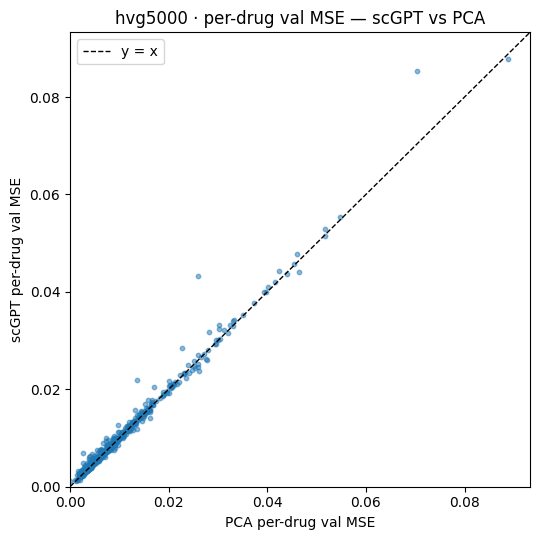

scGPT beats PCA on 208 / 545 heads (mean PCA=0.0102, mean scGPT=0.0105).


In [7]:
finite = np.isfinite(pca_mse) & np.isfinite(scg_mse)
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(pca_mse[finite], scg_mse[finite], s=10, alpha=0.5)
lim = [0, np.nanmax(np.concatenate([pca_mse[finite], scg_mse[finite]])) * 1.05]
ax.plot(lim, lim, 'k--', lw=1, label='y = x')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('PCA per-drug val MSE'); ax.set_ylabel('scGPT per-drug val MSE')
ax.set_title('hvg5000 · per-drug val MSE — scGPT vs PCA'); ax.legend()
fig.tight_layout(); fig.savefig(OUT / 'per_drug_scatter_pca_vs_scgpt.png', dpi=150)
plt.show()
n_better = int((scg_mse[finite] < pca_mse[finite]).sum())
print(f'scGPT beats PCA on {n_better} / {int(finite.sum())} heads '
      f'(mean PCA={np.nanmean(pca_mse):.4f}, mean scGPT={np.nanmean(scg_mse):.4f}).')

## Training curves — `hvg5000` all-drugs (val MSE per epoch)

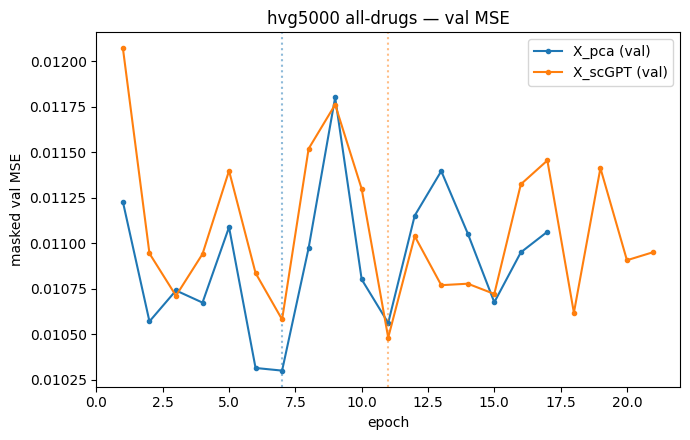

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for r, res in [('X_pca', pca_res), ('X_scGPT', scg_res)]:
    h = res['history']
    ax.plot(range(1, len(h.val_mse) + 1), h.val_mse, marker='o', ms=3, label=f'{r} (val)')
    ax.axvline(h.best_epoch, color=ax.lines[-1].get_color(), ls=':', alpha=0.5)
ax.set_xlabel('epoch'); ax.set_ylabel('masked val MSE')
ax.set_title('hvg5000 all-drugs — val MSE'); ax.legend()
fig.tight_layout(); fig.savefig(OUT / 'training_curves_pca_vs_scgpt.png', dpi=150)
plt.show()

## Outputs

Matrix tables + figures → `notebooks/outputs/`; full per-run artifacts (weights, history,
per-drug CSV, `run_meta.json`) under each `runs/<id>/`, indexed in `runs/runs_index.csv`.

In [9]:
print('outputs/:')
for p in sorted(OUT.glob('matrix_*')) + sorted(OUT.glob('*pca_vs_scgpt*')):
    print('  ', p.name)
print('run dirs:')
for k, res in results.items():
    print('  ', k, '->', Path(res['run_dir']).name)

outputs/:
   matrix_all_drugs.csv
   matrix_single_paclitaxel.csv
   per_drug_pca_vs_scgpt.csv
   per_drug_scatter_pca_vs_scgpt.png
   training_curves_pca_vs_scgpt.png
   training_pca_vs_scgpt_summary.csv
run dirs:
   hvg5000|X_pca|all_drugs -> 20260627_191310_multitask_X_pca_all_drugs
   hvg5000|X_pca|single_paclitaxel -> 20260627_191350_multitask_X_pca_subset_K1
   hvg5000|X_scGPT|all_drugs -> 20260627_191401_multitask_X_scGPT_all_drugs
   hvg5000|X_scGPT|single_paclitaxel -> 20260627_191449_multitask_X_scGPT_subset_K1
   all_genes|X_pca|all_drugs -> 20260627_191502_multitask_X_pca_all_drugs
   all_genes|X_pca|single_paclitaxel -> 20260627_191533_multitask_X_pca_subset_K1
   all_genes|X_scGPT|all_drugs -> 20260627_191546_multitask_X_scGPT_all_drugs
   all_genes|X_scGPT|single_paclitaxel -> 20260627_191624_multitask_X_scGPT_subset_K1
